In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt


## Bloque 1

In [27]:
# 1. CARGA DE DATOS
print("Cargando datasets completos...")
products = pd.read_csv('../data/products.csv.zip')
orders = pd.read_csv('../data/orders.csv.zip')
order_details = pd.read_csv('../data/order_products__prior.csv.zip')
print("¡Datos cargados correctamente!")


Cargando datasets completos...
¡Datos cargados correctamente!


In [ ]:
# 2. PREPROCESAMIENTO Y CRUCE DE TABLAS
print("Fusionando tablas")

# Unimos detalle de productos con órdenes para obtener (Usuario, Producto)
merged_data = pd.merge(order_details, orders[['order_id', 'user_id']], on='order_id')

# Procesamos el dataset entero. 
total_usuarios = merged_data['user_id'].nunique()
total_transacciones = len(merged_data)

print(f"¡Filtros eliminados! Analizando {total_transacciones:,} transacciones de {total_usuarios:,} usuarios.")

Fusionando tablas (esto puede tardar un poco con todos los datos)...
¡Filtros eliminados! Analizando 32,434,489 transacciones de 206,209 usuarios.


In [ ]:
# 3. CREACIÓN DE LA MATRIZ DE UTILIDAD (Sparse)

print("Creando matriz dispersa Usuarios x Productos")

# Contamos transacciones
user_product_counts = merged_data.groupby(['user_id', 'product_id']).size().reset_index(name='count')

# Mapeo de IDs reales a índices de matriz (0, 1, 2...)
user_product_counts['user_id'] = user_product_counts['user_id'].astype('category')
user_product_counts['product_id'] = user_product_counts['product_id'].astype('category')

user_ids = user_product_counts['user_id'].cat.codes
product_ids = user_product_counts['product_id'].cat.codes

# Creamos la matriz dispersa
sparse_matrix = csr_matrix((user_product_counts['count'], (user_ids, product_ids)))

print(f"Matriz Masiva creada: {sparse_matrix.shape} (Usuarios x Productos)")
print(f"Grado de dispersión (Sparsity): {100 * (1 - sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1])):.4f}%")

Creando matriz dispersa Usuarios x Productos (Masiva)...
Matriz Masiva creada: (206209, 49677) (Usuarios x Productos)
Grado de dispersión (Sparsity): 99.8701%


In [ ]:
# 4. APLICACIÓN DE SVD TRUNCADO (Técnica Unidad 1)
# Con el dataset completo, k=10 componentes podrían capturar perfiles más generales.
k_components = 10

print(f"Aplicando SVD con k={k_components} a todo el dataset...")
svd = TruncatedSVD(n_components=k_components, random_state=42)
user_profiles_reduced = svd.fit_transform(sparse_matrix)

print("¡Reducción de dimensionalidad completada!")

Aplicando SVD con k=10 a todo el dataset...
¡Reducción de dimensionalidad completada!


In [ ]:
# 5. INTERPRETACIÓN DE RESULTADOS

# Diccionario para traducir códigos de matriz a nombres reales
product_cat = user_product_counts['product_id'].cat.categories
product_code_to_id = dict(enumerate(product_cat))

def mostrar_perfil(component_idx, n_top=5):
    comp_row = svd.components_[component_idx]
    # Ordenamos por peso absoluto (tanto positivo como negativo importa en SVD)
    sorted_indices = np.argsort(np.abs(comp_row))[::-1][:n_top]
    
    print(f"\n--- Perfil Latente {component_idx + 1} (Principales Productos) ---")
    for idx in sorted_indices:
        real_prod_id = product_code_to_id[idx]
        prod_name = products[products['product_id'] == real_prod_id]['product_name'].values
        if len(prod_name) > 0:
            weight = comp_row[idx]
            # El signo (+/-) indica correlación con el concepto
            print(f"  - {prod_name[0]} (Peso: {weight:.4f})")

# Mostramos los primeros perfiles descubiertos en la data completa
mostrar_perfil(0) 
mostrar_perfil(1)
mostrar_perfil(2)



--- Perfil Latente 1 (Principales Productos) ---
  - Banana (Peso: 0.4284)
  - Bag of Organic Bananas (Peso: 0.3670)
  - Organic Strawberries (Peso: 0.2901)
  - Organic Baby Spinach (Peso: 0.2374)
  - Organic Hass Avocado (Peso: 0.2372)

--- Perfil Latente 2 (Principales Productos) ---
  - Banana (Peso: 0.7305)
  - Bag of Organic Bananas (Peso: -0.5555)
  - Organic Hass Avocado (Peso: -0.1971)
  - Organic Strawberries (Peso: -0.1000)
  - Organic Raspberries (Peso: -0.0992)

--- Perfil Latente 3 (Principales Productos) ---
  - Bag of Organic Bananas (Peso: 0.5324)
  - Organic Baby Spinach (Peso: -0.3460)
  - Banana (Peso: 0.3237)
  - Organic Avocado (Peso: -0.2302)
  - Limes (Peso: -0.1897)


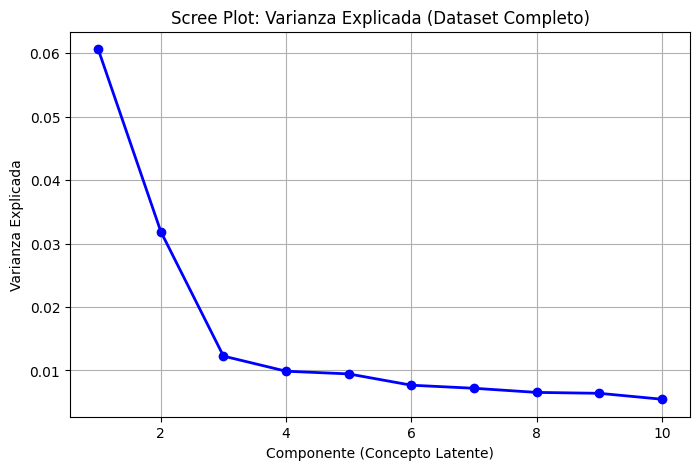

In [ ]:
# 6. SCREE PLOT
# explained_variance = svd.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, k_components + 1), explained_variance, 'bo-', linewidth=2)
plt.title('Scree Plot: Varianza Explicada (Dataset Completo)')
plt.xlabel('Componente (Concepto Latente)')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()

## Bloque 2


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
import zipfile

In [ ]:
# 1. CARGA DE DATOS

print("Cargando datos...")

# Usamos z.open para leer sin descomprimir
products = pd.read_csv('../data/products.csv.zip')
order_details = pd.read_csv('../data/order_products__prior.csv.zip')
print(f"Transacciones cargadas: {len(order_details):,}")

Cargando datos...
Transacciones cargadas: 32,434,489


In [ ]:
# 2. PREPARACIÓN DE LA "CESTA DE COMPRA" (BASKET)

# Para FP-Growth, necesitamos una matriz donde:
# Filas = Órdenes (Tickets)
# Columnas = Productos
# Valor = True/False (¿Compró el producto?)

# Para que la memoria RAM aguante, nos enfocaremos en los productos "Top Sellers".
# Analizaremos TODAS las órdenes, pero solo buscando relaciones entre los 100 productos más populares.
TOP_N_PRODUCTS = 100

print(f"Identificando los {TOP_N_PRODUCTS} productos más vendidos...")
top_products_counts = order_details['product_id'].value_counts().head(TOP_N_PRODUCTS)
top_product_ids = top_products_counts.index.tolist()

# Filtramos el dataset para quedarnos solo con transacciones de estos productos
df_filtered = order_details[order_details['product_id'].isin(top_product_ids)]

print(f"Registros después del filtrado (solo Top {TOP_N_PRODUCTS}): {len(df_filtered):,}")

# Hacemos el cruce con nombres de productos para que sea legible
df_merged = pd.merge(df_filtered, products[['product_id', 'product_name']], on='product_id')

print("Transformando a formato 'Cesta' (One-Hot Encoding)... Esto puede tardar unos segundos.")

# Creamos la matriz Transacción x Producto

basket = (df_merged.groupby(['order_id', 'product_name'])['product_id']
          .count().unstack().reset_index().fillna(0)
          .set_index('order_id'))


basket = basket.astype(bool)

print(f"Matriz de Cesta lista: {basket.shape} (Órdenes x Productos)")

Identificando los 100 productos más vendidos...
Registros después del filtrado (solo Top 100): 7,483,881
Transformando a formato 'Cesta' (One-Hot Encoding)... Esto puede tardar unos segundos.
Matriz de Cesta lista: (2351240, 100) (Órdenes x Productos)


In [ ]:
# ==========================================
# 3. APLICACIÓN DE FP-GROWTH
=
# Buscamos "Itemsets Frecuentes": grupos de productos que aparecen juntos frecuentemente.
# min_support=0.01 significa que el producto/grupo debe aparecer en al menos el 1% de las órdenes.
# Con 3 millones de órdenes, 1% son 30,000 ventas. Es un umbral alto y sólido.

print("Ejecutando algoritmo FP-Growth...")
frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)

print(f"¡Éxito! Se encontraron {len(frequent_itemsets)} conjuntos de items frecuentes.")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(5))

Ejecutando algoritmo FP-Growth...
¡Éxito! Se encontraron 130 conjuntos de items frecuentes.
     support                  itemsets
10  0.200985                  (Banana)
5   0.161383  (Bag of Organic Bananas)
11  0.112572    (Organic Strawberries)
2   0.102891    (Organic Baby Spinach)
6   0.090839    (Organic Hass Avocado)


In [12]:
# ==========================================
# 4. GENERACIÓN DE REGLAS DE ASOCIACIÓN
# ==========================================
# Ahora calculamos las reglas: "Si compra A -> entonces compra B"
# metric="lift": El Lift nos dice qué tan fuerte es la asociación comparado con el azar.
# Lift > 1 significa que hay una relación positiva real.

print("Generando Reglas de Asociación...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Ordenamos por confianza (probabilidad de que ocurra el consecuente dado el antecedente)
rules = rules.sort_values(by='confidence', ascending=False)

print(f"Reglas encontradas: {len(rules)}")

Generando Reglas de Asociación...
Reglas encontradas: 48


In [13]:
# ==========================================
# 5. ANÁLISIS DE RESULTADOS (Estrategia de Ventas)
# ==========================================

print("\n--- TOP 5 ESTRATEGIAS DE BUNDLING (PAQUETES) ---")
# Mostramos las reglas más fuertes
for i, row in rules.head(5).iterrows():
    antecedents = list(row['antecedents'])[0]
    consequents = list(row['consequents'])[0]
    support = row['support']
    conf = row['confidence']
    lift = row['lift']
    
    print(f"Regla: Si compra '{antecedents}' -> Recomendar '{consequents}'")
    print(f"   - Confianza: {conf*100:.1f}% (Probabilidad de compra)")
    print(f"   - Lift: {lift:.2f}x (Más probable que el azar)")
    print("-" * 30)


--- TOP 5 ESTRATEGIAS DE BUNDLING (PAQUETES) ---
Regla: Si compra 'Organic Fuji Apple' -> Recomendar 'Banana'
   - Confianza: 37.9% (Probabilidad de compra)
   - Lift: 1.88x (Más probable que el azar)
------------------------------
Regla: Si compra 'Honeycrisp Apple' -> Recomendar 'Banana'
   - Confianza: 35.6% (Probabilidad de compra)
   - Lift: 1.77x (Más probable que el azar)
------------------------------
Regla: Si compra 'Cucumber Kirby' -> Recomendar 'Banana'
   - Confianza: 33.0% (Probabilidad de compra)
   - Lift: 1.64x (Más probable que el azar)
------------------------------
Regla: Si compra 'Organic Avocado' -> Recomendar 'Banana'
   - Confianza: 30.2% (Probabilidad de compra)
   - Lift: 1.50x (Más probable que el azar)
------------------------------
Regla: Si compra 'Seedless Red Grapes' -> Recomendar 'Banana'
   - Confianza: 29.7% (Probabilidad de compra)
   - Lift: 1.48x (Más probable que el azar)
------------------------------


C:\Users\lafp0\AppData\Local\Temp\ipykernel_39064\3313875474.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
C:\Users\lafp0\AppData\Local\Temp\ipykernel_39064\3313875474.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: list(x)[0])


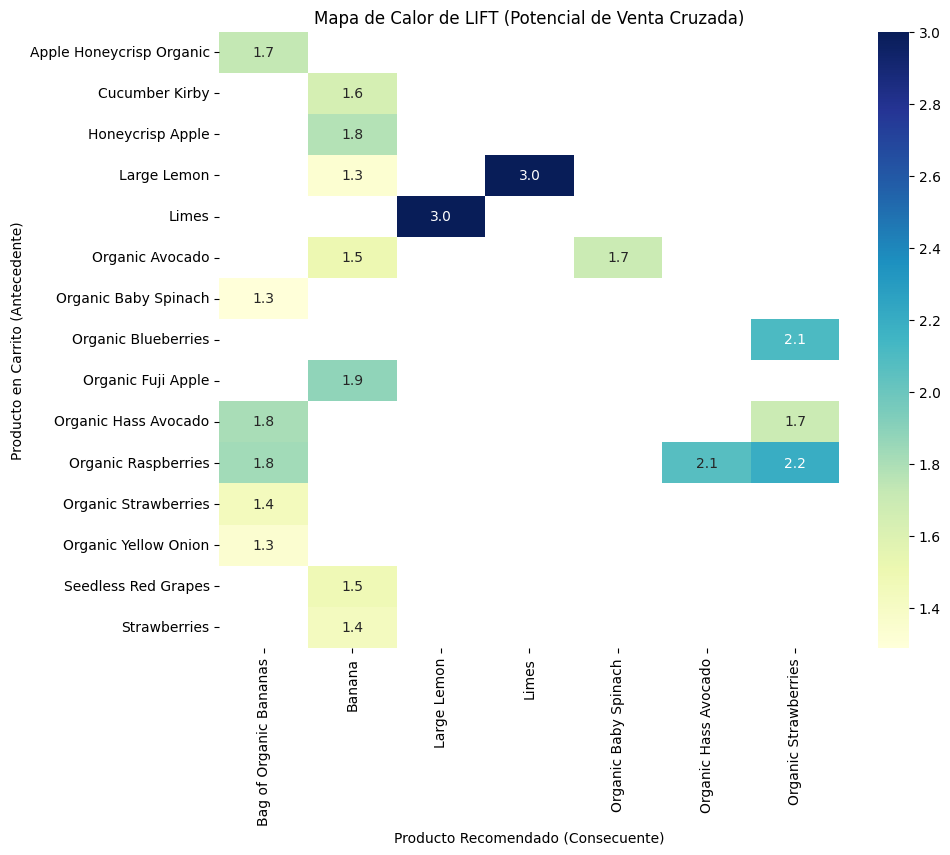

In [14]:
# ==========================================
# 6. VISUALIZACIÓN DEL MAPA DE CALOR
# ==========================================
# Visualizamos la relación Lift entre los productos más conectados
# Filtramos las top reglas para no saturar el gráfico
top_rules = rules.head(20)

# Preparamos datos para el heatmap
# Convertimos frozensets a strings para graficar
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: list(x)[0])

pivot_rules = top_rules.pivot(index='antecedents_str', 
                            columns='consequents_str', 
                            values='lift')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_rules, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Mapa de Calor de LIFT (Potencial de Venta Cruzada)')
plt.xlabel('Producto Recomendado (Consecuente)')
plt.ylabel('Producto en Carrito (Antecedente)')
plt.show()

In [15]:
import pandas as pd
import numpy as np
import networkx as nx
import community.community_louvain as community_louvain # Librería python-louvain
import matplotlib.pyplot as plt
import zipfile

In [16]:
# ==========================================
# 1. CARGA DE DATOS (Top 100 Productos)
# ==========================================
print("Cargando y filtrando datos...")

try:
    with zipfile.ZipFile('../data/order_products__prior.csv.zip', 'r') as z:
        order_details = pd.read_csv(z.open('order_products__prior.csv'))
    
    with zipfile.ZipFile('../data/products.csv.zip', 'r') as z:
        products = pd.read_csv(z.open('products.csv'))

    # Filtramos Top 100 para que el grafo sea visualizable y procesable
    top_100 = order_details['product_id'].value_counts().head(100).index
    df_filtered = order_details[order_details['product_id'].isin(top_100)]
    
    # Pegamos los nombres reales
    df_merged = pd.merge(df_filtered, products[['product_id', 'product_name']], on='product_id')
    
    print(f"Datos listos: {len(df_merged):,} registros (Top 100 productos).")

except Exception as e:
    print(f"Error: {e}")

Cargando y filtrando datos...
Datos listos: 7,483,881 registros (Top 100 productos).


In [17]:
# ==========================================
# 2. CONSTRUCCIÓN DEL GRAFO (Técnica Big Data)
# ==========================================
print("Construyendo la red de co-compras...")

# Hacemos un "Self-Join": Cruzamos la tabla consigo misma usando 'order_id'
# Esto nos da pares: (Producto A, Producto B) que estaban en la misma orden.
df_pairs = pd.merge(df_merged, df_merged, on='order_id')

# Filtramos para no tener pares duplicados (A, B) y (B, A) o (A, A)
# Usamos product_id_x < product_id_y para asegurar orden único
df_pairs = df_pairs[df_pairs['product_id_x'] < df_pairs['product_id_y']]

# Contamos la fuerza de la conexión (Peso de la arista)
edge_weights = df_pairs.groupby(['product_name_x', 'product_name_y']).size().reset_index(name='weight')

print(f"Se encontraron {len(edge_weights)} conexiones únicas entre productos.")

# Inicializamos el grafo
G = nx.Graph()

# Añadimos las aristas con sus pesos
for _, row in edge_weights.iterrows():
    G.add_edge(row['product_name_x'], row['product_name_y'], weight=row['weight'])

print(f"Grafo creado: {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas.")

Construyendo la red de co-compras...
Se encontraron 4945 conexiones únicas entre productos.
Grafo creado: 100 nodos y 4945 aristas.


In [18]:
# ==========================================
# 3. ANÁLISIS DE CENTRALIDAD (PageRank - Unidad 5)
# ==========================================
# PageRank nos dice cuáles son los productos "Más Importantes" estructuralmente.
# Un producto tiene alto PR si se compra con otros productos importantes.

pagerank = nx.pagerank(G, weight='weight')
# Ordenamos
sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)

print("\n--- Top 5 Productos 'Autoridad' (PageRank) ---")
for prod, score in sorted_pagerank[:5]:
    print(f"{prod}: {score:.4f}")


--- Top 5 Productos 'Autoridad' (PageRank) ---
Banana: 0.0432
Bag of Organic Bananas: 0.0373
Organic Strawberries: 0.0312
Organic Baby Spinach: 0.0305
Organic Hass Avocado: 0.0269


In [19]:
# ==========================================
# 4. DETECCIÓN DE COMUNIDADES (Louvain - Unidad 5)
# ==========================================
# Esto agrupará los productos en "Clusters" naturales (ej. Frutas, Lácteos, etc.)
# sin que nosotros le digamos la categoría.

partition = community_louvain.best_partition(G, weight='weight')

# Organizar resultados
communities = {}
for node, comm_id in partition.items():
    if comm_id not in communities:
        communities[comm_id] = []
    communities[comm_id].append(node)

print(f"\n--- Comunidades Detectadas: {len(communities)} ---")
for comm_id, items in communities.items():
    if len(items) > 5: # Solo mostrar comunidades relevantes
        print(f"\nComunidad {comm_id} ({len(items)} productos):")
        print(f"Ejemplos: {items[:5]}...") # Mostramos los primeros 5


--- Comunidades Detectadas: 4 ---

Comunidad 2 (36 productos):
Ejemplos: ['100% Raw Coconut Water', 'Apple Honeycrisp Organic', 'Bag of Organic Bananas', 'Half & Half', 'Hass Avocados']...

Comunidad 1 (37 productos):
Ejemplos: ['100% Whole Wheat Bread', '2% Reduced Fat Milk', 'Asparagus', 'Banana', 'Bartlett Pears']...

Comunidad 3 (24 productos):
Ejemplos: ['Carrots', 'Fresh Cauliflower', 'Grated Parmesan', 'Green Bell Pepper', 'Michigan Organic Kale']...


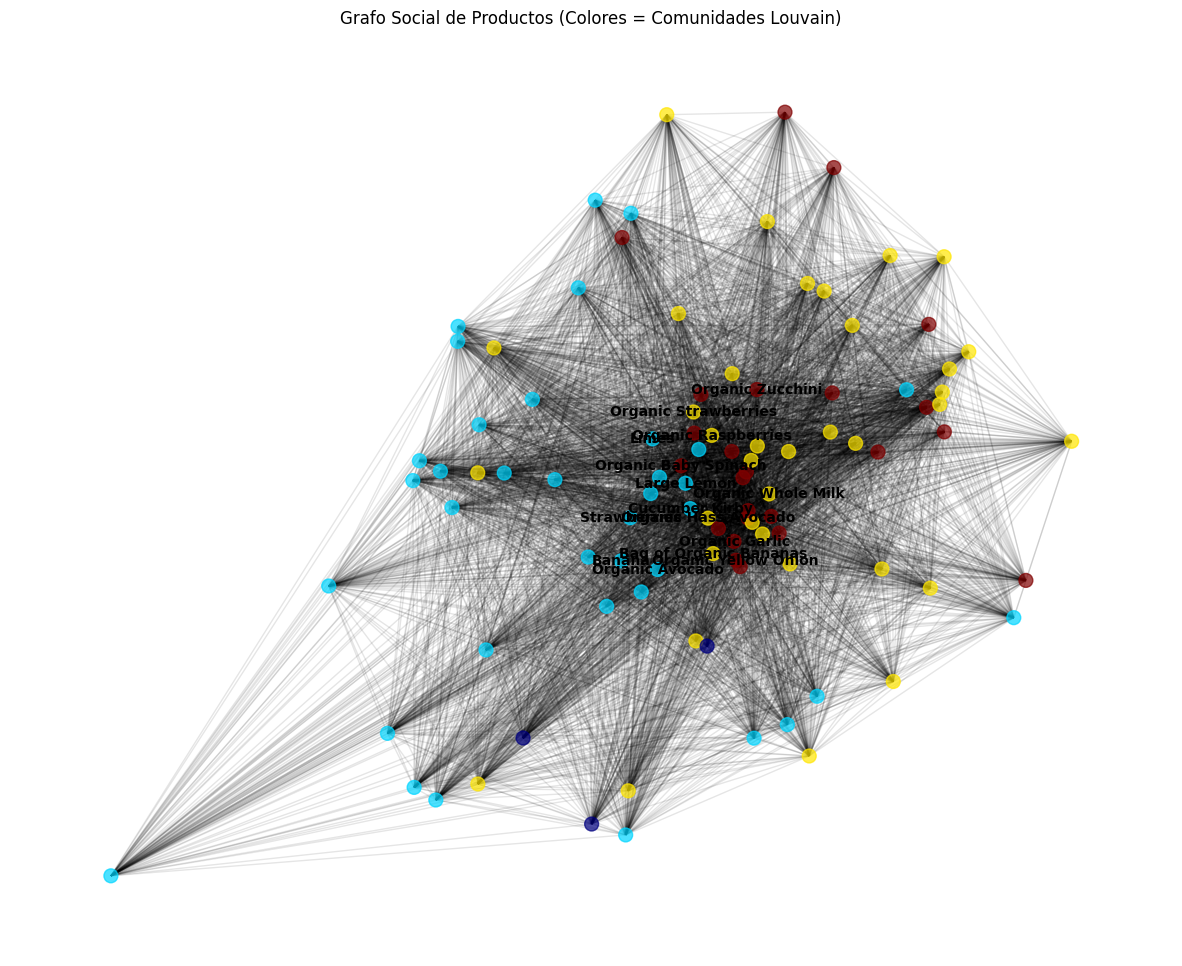

In [20]:
# ==========================================
# 5. VISUALIZACIÓN DEL GRAFO
# ==========================================
plt.figure(figsize=(15, 12))

# Posicionamiento de los nodos (Spring Layout usa fuerzas de atracción/repulsión)
pos = nx.spring_layout(G, k=0.15, seed=42)

# Colorear nodos según su comunidad
node_colors = [partition[node] for node in G.nodes()]

# Dibujar
nx.draw_networkx_nodes(G, pos, node_size=100, cmap=plt.cm.jet, node_color=node_colors, alpha=0.7)
nx.draw_networkx_edges(G, pos, alpha=0.1)

# Etiquetas (solo para los productos más importantes para no saturar)
top_nodes = [x[0] for x in sorted_pagerank[:15]] # Solo etiquetamos el Top 15
labels = {node: node for node in G.nodes() if node in top_nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

plt.title("Grafo Social de Productos (Colores = Comunidades Louvain)")
plt.axis('off')
plt.show()

In [21]:
# ==========================================
# 1. DEFINICIÓN DEL ESCENARIO (CARRITO DE USUARIO)
# ==========================================
# Imaginemos un usuario con perfil "Healthy" (Comunidad 0)
# Tiene estos productos en su carrito ahora mismo:
carrito_usuario = ['Bag of Organic Bananas', 'Organic Hass Avocado']

print(f"🛒 Carrito del Usuario: {carrito_usuario}")

🛒 Carrito del Usuario: ['Bag of Organic Bananas', 'Organic Hass Avocado']


In [22]:
# ==========================================
# 2. GENERACIÓN DE CANDIDATOS (Recuperación)
# ==========================================
# Usamos las Reglas de Asociación (Unidad 2) para buscar candidatos.
# Buscamos reglas donde el antecedente esté en el carrito.

print("Buscando candidatos basados en reglas...")

# Filtramos las reglas generadas en el Bloque 2
# Convertimos frozensets a strings para buscar fácil
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: list(x)[0])
rules['consequents_str'] = rules['consequents'].apply(lambda x: list(x)[0])

candidates = rules[rules['antecedents_str'].isin(carrito_usuario)].copy()

# Nos quedamos con los productos sugeridos únicos
unique_candidates = candidates['consequents_str'].unique()

print(f"Candidates encontrados: {len(unique_candidates)}")
print(f"Ejemplos: {unique_candidates[:5]}")

Buscando candidatos basados en reglas...
Candidates encontrados: 7
Ejemplos: ['Bag of Organic Bananas' 'Organic Strawberries' 'Organic Hass Avocado'
 'Organic Baby Spinach' 'Organic Raspberries']


In [23]:
# ==========================================
# 3. INGENIERÍA DE CARACTERÍSTICAS (Feature Engineering)
# ==========================================
# Para ordenar (Rankear), necesitamos métricas. Vamos a construir una tabla de features.
# Feature 1: Confidence (Probabilidad de compra dado el carrito) - Viene de FP-Growth
# Feature 2: Lift (Fuerza de la conexión) - Viene de FP-Growth
# Feature 3: PageRank (Autoridad global del producto) - Viene del Grafo
# Feature 4: Community Match (¿Pertenece al mismo barrio que el carrito?) - Viene de Louvain

ranking_table = pd.DataFrame({'product': unique_candidates})

# --- A. Feature de Reglas (Max Confidence/Lift si hay múltiples reglas) ---
def get_rule_metrics(product):
    # Buscamos reglas que lleven a este producto desde items del carrito
    matches = rules[
        (rules['antecedents_str'].isin(carrito_usuario)) & 
        (rules['consequents_str'] == product)
    ]
    if matches.empty:
        return 0, 0
    return matches['confidence'].max(), matches['lift'].max()

ranking_table[['confidence', 'lift']] = ranking_table['product'].apply(
    lambda x: pd.Series(get_rule_metrics(x))
)

# --- B. Feature de Grafo (PageRank) ---
# Mapeamos el PageRank calculado en el bloque 3
ranking_table['pagerank_score'] = ranking_table['product'].map(pagerank).fillna(0)

# --- C. Feature de Comunidad (Community Match) ---
# Determinamos la comunidad dominante del carrito
comm_ids = [partition.get(item, -1) for item in carrito_usuario]
# Usamos la moda (la comunidad más frecuente en el carrito)
carrito_comm = max(set(comm_ids), key=comm_ids.count) 

# Vemos si el candidato es de la misma comunidad
ranking_table['community_id'] = ranking_table['product'].map(partition).fillna(-1)
ranking_table['is_same_community'] = (ranking_table['community_id'] == carrito_comm).astype(int)

print("\n--- Tabla de Características para LTR (Primeras 5 filas) ---")
print(ranking_table.head())


--- Tabla de Características para LTR (Primeras 5 filas) ---
                  product  confidence      lift  pagerank_score  community_id  \
0  Bag of Organic Bananas    0.291880  1.808621        0.037311             2   
1    Organic Strawberries    0.190997  1.696674        0.031199             2   
2    Organic Hass Avocado    0.164293  1.808621        0.026939             2   
3    Organic Baby Spinach    0.163406  1.588154        0.030476             3   
4     Organic Raspberries    0.120763  2.071710        0.017815             2   

   is_same_community  
0                  1  
1                  1  
2                  1  
3                  0  
4                  1  


In [24]:
# ==========================================
# 4. MODELO DE SCORING (LTR Pointwise)
# ==========================================
# En un sistema real usaríamos XGBoost Ranker.
# Para este proyecto, crearemos una "Función de Puntuación" manual (Heurística)
# que simula un modelo lineal aprendido: Score = w1*Conf + w2*Lift + w3*PR + w4*Comm

# Pesos hipotéticos (en un modelo real, estos se aprenden con Machine Learning)
w_conf = 0.4   # La probabilidad histórica pesa mucho
w_lift = 0.3   # La fuerza de atracción pesa
w_pr = 0.1     # La popularidad global ayuda un poco
w_comm = 0.2   # El contexto de comunidad ayuda

# Normalizamos para que las escalas no rompan el modelo
ranking_table['lift_norm'] = ranking_table['lift'] / ranking_table['lift'].max()
ranking_table['pr_norm'] = ranking_table['pagerank_score'] / ranking_table['pagerank_score'].max()

# Calculamos el Score Final
ranking_table['final_score'] = (
    (ranking_table['confidence'] * w_conf) +
    (ranking_table['lift_norm'] * w_lift) +
    (ranking_table['pr_norm'] * w_pr) +
    (ranking_table['is_same_community'] * w_comm)
)

In [25]:
# ==========================================
# 5. RESULTADO FINAL: EL RANKING
# ==========================================
final_ranking = ranking_table.sort_values(by='final_score', ascending=False)

print("\n" + "="*40)
print("   RECOMENDACIONES ORDENADAS (OUTPUT FINAL)")
print("="*40)
rank = 1
for i, row in final_ranking.head(10).iterrows():
    comm_tag = "✅ Misma Comunidad" if row['is_same_community'] else "❌ Otra Comunidad"
    print(f"#{rank} {row['product']}")
    print(f"   Score: {row['final_score']:.4f} | Conf: {row['confidence']:.2f} | Lift: {row['lift']:.2f}")
    print(f"   {comm_tag} (PR: {row['pagerank_score']:.4f})")
    print("-" * 30)
    rank += 1


   RECOMENDACIONES ORDENADAS (OUTPUT FINAL)
#1 Bag of Organic Bananas
   Score: 0.6787 | Conf: 0.29 | Lift: 1.81
   ✅ Misma Comunidad (PR: 0.0373)
------------------------------
#2 Organic Strawberries
   Score: 0.6057 | Conf: 0.19 | Lift: 1.70
   ✅ Misma Comunidad (PR: 0.0312)
------------------------------
#3 Organic Hass Avocado
   Score: 0.5998 | Conf: 0.16 | Lift: 1.81
   ✅ Misma Comunidad (PR: 0.0269)
------------------------------
#4 Organic Raspberries
   Score: 0.5961 | Conf: 0.12 | Lift: 2.07
   ✅ Misma Comunidad (PR: 0.0178)
------------------------------
#5 Apple Honeycrisp Organic
   Score: 0.5069 | Conf: 0.06 | Lift: 1.73
   ✅ Misma Comunidad (PR: 0.0119)
------------------------------
#6 Organic Baby Spinach
   Score: 0.3770 | Conf: 0.16 | Lift: 1.59
   ❌ Otra Comunidad (PR: 0.0305)
------------------------------
#7 Organic Yellow Onion
   Score: 0.2646 | Conf: 0.06 | Lift: 1.34
   ❌ Otra Comunidad (PR: 0.0165)
------------------------------


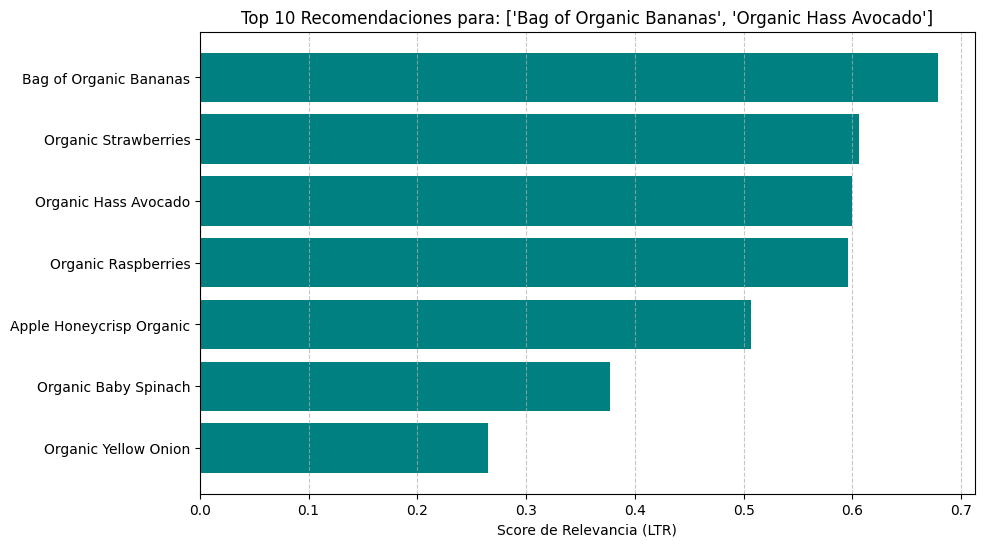

In [26]:
# ==========================================
# 6. GRÁFICO DE IMPORTANCIA
# ==========================================
plt.figure(figsize=(10, 6))
# Top 10 productos
top_10 = final_ranking.head(10)
plt.barh(top_10['product'][::-1], top_10['final_score'][::-1], color='teal')
plt.xlabel('Score de Relevancia (LTR)')
plt.title(f'Top 10 Recomendaciones para: {carrito_usuario}')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()